In [18]:
import pandas as pd
import networkx as nx
import pickle

In [2]:
columns=['UNIPROT_SOURCE', 'ENTREZ_SOURCE', 'UNIPROT_TARGET', 'ENTREZ_TARGET', 'CONFIDENCE_SCORE', 'EXPERIMENT_DETAILS']
ppi_df = pd.read_csv("./hippie_current.txt", sep='\t', header=None, names=columns,)
ppi = ppi_df.dropna()
ppi

,UNIPROT_SOURCE,ENTREZ_SOURCE,UNIPROT_TARGET,ENTREZ_TARGET,CONFIDENCE_SCORE,EXPERIMENT_DETAILS
1,AL1A1_HUMAN,216.0,AL1A1_HUMAN,216.0,0.76,"experiments:in vivo,Two-hybrid;pmids:12081471,..."
2,ITA7_HUMAN,3679.0,ACHA_HUMAN,1134.0,0.73,"experiments:in vivo,Affinity Capture-Western,a..."
3,NEB1_HUMAN,55607.0,ACTG_HUMAN,71.0,0.78,"experiments:in vitro,in vivo,cross-linking stu..."
4,SRGN_HUMAN,5552.0,CD44_HUMAN,960.0,0.63,"experiments:in vivo;pmids:9334256,16189514,167..."
5,GRB7_HUMAN,2886.0,ERBB2_HUMAN,2064.0,0.90,"experiments:in vitro,in vivo,Reconstituted Com..."
...,...,...,...,...,...,...
1118995,NUP43_HUMAN,348995.0,SRS10_HUMAN,10772.0,0.63,experiments:bioid;pmids:37689310;sources:BioGRID
1118996,MYCN_HUMAN,4613.0,GTF2I_HUMAN,2969.0,0.63,experiments:affinity chromatography technology...
1118997,PCNT_HUMAN,5116.0,K1468_HUMAN,57614.0,0.63,experiments:cross-linking study;pmids:40437099...
1118998,MYCN_HUMAN,4613.0,TF3C2_HUMAN,2976.0,0.63,experiments:affinity chromatography technology...


In [7]:
node_names = set(ppi['UNIPROT_SOURCE'].unique()) | set(ppi['UNIPROT_TARGET'].unique())
len(node_names)
node_name_map = {node_name:i for i,node_name in enumerate(node_names)}
ppi['UNIPROT_SOURCE_index'] = ppi['UNIPROT_SOURCE'].apply(lambda x: node_name_map[x])
ppi['UNIPROT_TARGET_index'] = ppi['UNIPROT_TARGET'].apply(lambda x: node_name_map[x])
ppi['relation'] = ['ppi']*len(ppi)
ppi

,UNIPROT_SOURCE,ENTREZ_SOURCE,UNIPROT_TARGET,ENTREZ_TARGET,CONFIDENCE_SCORE,EXPERIMENT_DETAILS,UNIPROT_SOURCE_index,UNIPROT_TARGET_index,relation
1,AL1A1_HUMAN,216.0,AL1A1_HUMAN,216.0,0.76,"experiments:in vivo,Two-hybrid;pmids:12081471,...",7019,7019,ppi
2,ITA7_HUMAN,3679.0,ACHA_HUMAN,1134.0,0.73,"experiments:in vivo,Affinity Capture-Western,a...",2667,14168,ppi
3,NEB1_HUMAN,55607.0,ACTG_HUMAN,71.0,0.78,"experiments:in vitro,in vivo,cross-linking stu...",8999,3358,ppi
4,SRGN_HUMAN,5552.0,CD44_HUMAN,960.0,0.63,"experiments:in vivo;pmids:9334256,16189514,167...",1974,9239,ppi
5,GRB7_HUMAN,2886.0,ERBB2_HUMAN,2064.0,0.90,"experiments:in vitro,in vivo,Reconstituted Com...",3589,6746,ppi
...,...,...,...,...,...,...,...,...,...
1118995,NUP43_HUMAN,348995.0,SRS10_HUMAN,10772.0,0.63,experiments:bioid;pmids:37689310;sources:BioGRID,3940,10927,ppi
1118996,MYCN_HUMAN,4613.0,GTF2I_HUMAN,2969.0,0.63,experiments:affinity chromatography technology...,2225,15195,ppi
1118997,PCNT_HUMAN,5116.0,K1468_HUMAN,57614.0,0.63,experiments:cross-linking study;pmids:40437099...,4755,9496,ppi
1118998,MYCN_HUMAN,4613.0,TF3C2_HUMAN,2976.0,0.63,experiments:affinity chromatography technology...,2225,6665,ppi


In [8]:
source_nodes = ppi[['UNIPROT_SOURCE_index','UNIPROT_SOURCE', 'ENTREZ_SOURCE']].copy()
source_nodes.columns = ["id", "name",'Entrez']

target_nodes = ppi[['UNIPROT_TARGET_index','UNIPROT_TARGET', 'ENTREZ_TARGET']].copy()
target_nodes.columns = ["id", "name",'Entrez']

nodes = pd.concat([source_nodes, target_nodes])

# Remove duplicates
nodes = nodes.drop_duplicates(subset=["id"])

# Neo4j label cleanup
nodes["label"] = ['Protein']*len(nodes)

# neo4j formatting
nodes = nodes.rename(columns={
    "id": "id:ID",
    "name": "name",
    "label": ":LABEL",
    'Entrez':'Entrez'
})
nodes.to_csv("./import/nodes.csv", index=False)
nodes

,id:ID,name,Entrez,:LABEL
1,7019,AL1A1_HUMAN,216.0,Protein
2,2667,ITA7_HUMAN,3679.0,Protein
3,8999,NEB1_HUMAN,55607.0,Protein
4,1974,SRGN_HUMAN,5552.0,Protein
5,3589,GRB7_HUMAN,2886.0,Protein
...,...,...,...,...
1110178,2686,O2AE1_HUMAN,81392.0,Protein
1113461,16036,P1L12_HUMAN,285877.0,Protein
1113796,7286,MARHB_HUMAN,441061.0,Protein
1114870,13721,CAN14_HUMAN,440854.0,Protein


In [10]:
# Build edge table
# --------------------------------------------------
edges = ppi[["UNIPROT_SOURCE_index", "relation", "UNIPROT_TARGET_index",'CONFIDENCE_SCORE', 'EXPERIMENT_DETAILS']].copy()

edges.columns = [":START_ID", ":TYPE", ":END_ID",'CONFIDENCE_SCORE', 'EXPERIMENT_DETAILS']

# Neo4j relationship formatting
edges[":TYPE"] = (
    edges[":TYPE"]
    .str.upper()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)
edges.to_csv("./import/edges.csv", index=False)

print("Done.")
print(f"Nodes: {len(nodes)}")
print(f"Edges: {len(edges)}")
edges

Done.
Nodes: 18809
Edges: 1105119


,:START_ID,:TYPE,:END_ID,CONFIDENCE_SCORE,EXPERIMENT_DETAILS
1,7019,PPI,7019,0.76,"experiments:in vivo,Two-hybrid;pmids:12081471,..."
2,2667,PPI,14168,0.73,"experiments:in vivo,Affinity Capture-Western,a..."
3,8999,PPI,3358,0.78,"experiments:in vitro,in vivo,cross-linking stu..."
4,1974,PPI,9239,0.63,"experiments:in vivo;pmids:9334256,16189514,167..."
5,3589,PPI,6746,0.90,"experiments:in vitro,in vivo,Reconstituted Com..."
...,...,...,...,...,...
1118995,3940,PPI,10927,0.63,experiments:bioid;pmids:37689310;sources:BioGRID
1118996,2225,PPI,15195,0.63,experiments:affinity chromatography technology...
1118997,4755,PPI,9496,0.63,experiments:cross-linking study;pmids:40437099...
1118998,2225,PPI,6665,0.63,experiments:affinity chromatography technology...


### Save PPIKG (confidence >= 0.7)

In [12]:
ppi_hc = ppi[ppi['CONFIDENCE_SCORE']>= 0.7]
ppi_hc.to_csv('ppi_hc.csv', index=False)

In [14]:
ppi_hc.head()

,UNIPROT_SOURCE,ENTREZ_SOURCE,UNIPROT_TARGET,ENTREZ_TARGET,CONFIDENCE_SCORE,EXPERIMENT_DETAILS,UNIPROT_SOURCE_index,UNIPROT_TARGET_index,relation
1,AL1A1_HUMAN,216.0,AL1A1_HUMAN,216.0,0.76,"experiments:in vivo,Two-hybrid;pmids:12081471,...",7019,7019,ppi
2,ITA7_HUMAN,3679.0,ACHA_HUMAN,1134.0,0.73,"experiments:in vivo,Affinity Capture-Western,a...",2667,14168,ppi
3,NEB1_HUMAN,55607.0,ACTG_HUMAN,71.0,0.78,"experiments:in vitro,in vivo,cross-linking stu...",8999,3358,ppi
5,GRB7_HUMAN,2886.0,ERBB2_HUMAN,2064.0,0.90,"experiments:in vitro,in vivo,Reconstituted Com...",3589,6746,ppi
6,PAK1_HUMAN,5058.0,ERBB2_HUMAN,2064.0,0.73,"experiments:in vivo,Affinity Capture-Western,a...",10942,6746,ppi


To networkx

In [20]:
G = nx.MultiDiGraph()
for i, row in ppi_hc.iterrows():
    G.add_node(row['UNIPROT_SOURCE'], Entrez_ID=row['ENTREZ_SOURCE'])
    G.add_node(row['UNIPROT_TARGET'], Entrez_ID=row['ENTREZ_TARGET'])
    G.add_edge(u_for_edge=row['UNIPROT_SOURCE'], v_for_edge=row['UNIPROT_TARGET'],
               rel='PPI',
               confidence=row['CONFIDENCE_SCORE'],
               evidence=row['EXPERIMENT_DETAILS'])

print(f"Added {G.number_of_nodes()} nodes and {G.number_of_edges()} edges to graph G")
with open("./ppi_kg.pkl",'wb') as f:
    pickle.dump(G,f)

Added 17042 nodes and 382526 edges to graph G


In [28]:
for node in G.nodes():
    print(node)
    pr_name = node.split("_")[0]
    print(pr_name)
    break

AL1A1_HUMAN
AL1A1


## KG proteins vs. GE proteins

In [23]:
adni_exp = pd.read_csv("../AD/data/ADNI/cleaned_gene_expression_data.csv", index_col=0)
ge_df = adni_exp.T

In [29]:
ge_proteins = set(ge_df.columns)
kg_proteins = set(node.split("_")[0] for node in G.nodes())

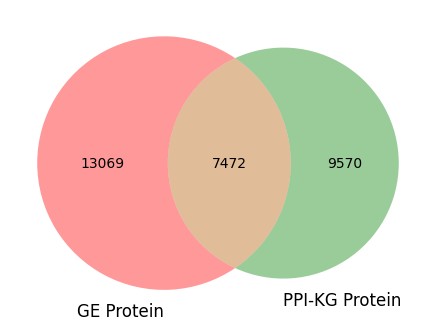

In [31]:
from matplotlib_venn import *
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
venn2(subsets=(ge_proteins,kg_proteins),
      set_labels=('GE Protein','PPI-KG Protein'),)
plt.show()

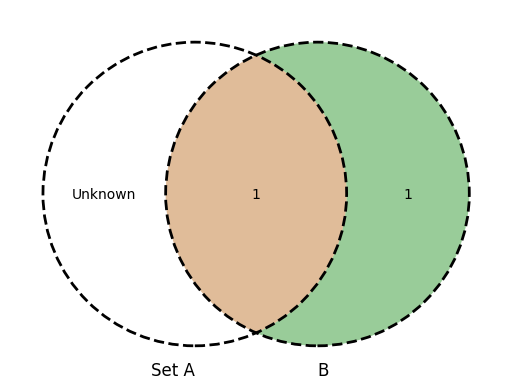

In [36]:
v = venn2(subsets={'10': 1, '01': 1, '11': 1}, set_labels = ('A', 'B'))
c = venn2_circles(subsets=(1, 1, 1), linestyle='dashed')
v.get_patch_by_id('10').set_alpha(1.0)
v.get_patch_by_id('10').set_color('white')
v.get_label_by_id('10').set_text('Unknown')
v.get_label_by_id('A').set_text('Set A')

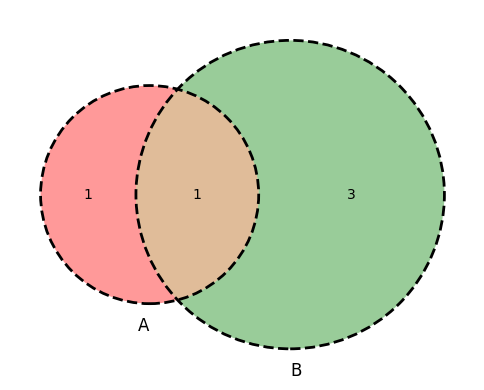

In [35]:
v = venn2(subsets=(set([1,2]), set([2,3,4,5])), 
          set_labels = ('A', 'B')) 
c = venn2_circles(subsets=(set([1,2]), set([2,3,4,5])), 
                  linestyle='dashed') 
# print("%0.2f" % (v.get_circle_radius(1)/v.get_circle_radius(0))) 